# Uczenie maszynowe. Lista 7
### Grupowanie (klasteryzacja)

##### Wstęp

Na poprzednich laboratoriach podejmowaliśmy zadania klasyfikacji, to znaczy uczenia (_indukcji_) funkcji pozwalającej przypisać pewne obiekty do określonych z góry kategorii. Bardziej ogólnie, posługiwaliśmy się narzędziami _uczenia nadzorowanego_, tzn. takiego, w którym mamy dostęp do pewnej reprezentacji "prawdy", np. w formie zbioru etykiet $Y$ skojarzonych z danymi $X$.

W praktyce jednak często bywa, że zbiór danych nie jest opatrzony etykietami, a mimo to chcielibyśmy wyekstrahować z niego informacje. Innymi słowy, mamy dostęp jedynie do zbioru $X$. Mówimy wówczas o _uczeniu nienadzorowanym_ (ang. _unsupervised learning_). Istotne podzadanie uczenia nienadzorowanego - i temat niniejszego laboratorium - stanowi **klasteryzacja** (lub **grupowanie**).

Zadanie klasteryzacji można intuicyjnie rozumieć jako "podzielenie na grupy" zadanego zbioru $X$. Bardziej formalnie, każdej próbce $(x \in \mathbb{R}^d)$ chcemy przyporządkować identyfikator $\hat{y}$ w taki sposób, że próbki o tym samym identyfikatorze $\hat{y_i}$ należą do jednej grupy (_klastra_ - nie mylić z _klasą_). Istotne jest, że opieramy się tu wyłącznie na geometrii zbioru danych, tj. grupujemy próbki leżące w pewnym sensie "blisko siebie".

W odróżnieniu od klasyfikacji, grupowanie rzadko kiedy bywa końcowym etapem analizy. Niemniej, może ono dostarczyć pewnych pośrednich informacji - niekompletnych, ale nadal użytecznych. Aby się o tym przekonać, rozważ następujące przykłady zastosowań klasteryzacji:
* zidentyfikowanie w zbiorze klientów sklepu grup o podobnych preferencjach,
* znalezienie w zbiorze obrazów medycznych rejonów o podobnych cechach wizualnych,
* wydzielenie w niezaanotowanym korpusie dokumentów zbliżonych tematycznie.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import cluster, datasets, metrics

Poniższy, oczywiście zupełnie zabawkowy, zbiór danych obrazuje problem klasteryzacji. Człowiek _wyraźnie widzi_ trzy oddzielne grupy punktów. Jak tę ideę wyrazić w formie algorytmu, zwłaszcza gdy zbiór jest zbyt wielowymiarowy by na niego "spojrzeć"?

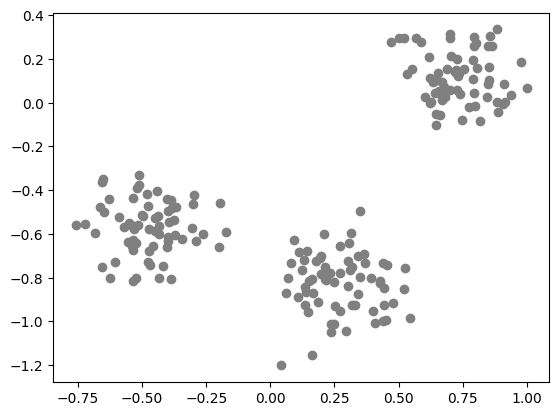

In [3]:
X, _ = datasets.make_blobs(n_samples=200, random_state=1009)
X = X / X.max()
plt.scatter(X[:, 0], X[:, 1], c='gray')

##### Algorytm k-średnich (k-means clustering)

Być może najprostszym (a jednocześnie zupełnie użytecznym w wielu praktycznych zastosowaniach) algorytmem grupowania jest algorytm _k-średnich_. W telegraficznym skrócie, algorytm ten polega na przypisaniu próbek w zbiorze do tzw. _centroidów_, czyli wektorów _średnich_ reprezentujących każdy klaster, w taki sposób, by zminimalizować tzw. _inercję_. Ponieważ z góry musimy założyć ile konkretnie tych wektorów będzie (parametr $k$), stąd mówimy o algorytmie _k-średnich_.

Procedura zaczyna się od inicjalizacji wektorów średnich (centroidów), być może losowo (np. przez wylosowanie w $d$-wymiarowej przestrzeni danych $k$ wektorów, albo wybranie $k$ punktów danych ze zbioru).
Następnie iteracyjnie powtarzane są dwa proste kroki:
1. dla każdego punktu w zbiorze sprawdzamy, do którego centroidu jest mu najbliżej,
1. dla każdego centroidu bierzemy tak zidentyfikowane punkty i obliczamy ich _średnią_ arytmetyczną, którą bierzemy jako nowe położenie centroidu.

Poniższa komórka zawiera implementację pojedynczej takiej iteracji.

In [4]:
def kmeans_step(dataset: np.ndarray, centers: np.ndarray):
    """Uproszczona implementacja pojedynczego kroku algorytmu k-średnich.
    dataset: (N, D)
    centers: (K, D)
    """
    # Krok 1.1: oblicz odległości euklidesowe pomiędzy punktami a centroidami
    # (N, 1, D) - (K, D) -> (N, K, D); norma w osi 2 -> (N, K)
    distances = np.linalg.norm(dataset[:, None, :] - centers, axis=2)

    # Krok 1.2: przypisz punkty danych do najbliższych im centroidów
    # (N,)
    indices = np.argmin(distances, axis=1)

    # Krok 2: oblicz nowe pozycje centroidów...
    new_centers = []
    for i in range(len(centers)):
        if np.any(indices==i):
            # ...przez uśrednienie pozycji wszystkich punktów "pasujących" do tego centroidu
            mean = dataset[indices==i].mean(axis=0)
        else:
            # nie zmieniaj pozycji jeśli żaden punkt nie został przypisany do klastra
            mean = centers[i]
        new_centers.append(mean)

    return indices, np.array(new_centers)

def show_step(dataset: np.ndarray, indices: np.ndarray, old_centers: np.ndarray, new_centers: np.ndarray, title: str = None) -> None:
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.scatter(dataset[:, 0], dataset[:, 1], c=indices, cmap='Set1', vmin=0, vmax=8)
    ax.scatter(old_centers[:, 0], old_centers[:, 1], marker='x', c='black', label='Poprzednie centra')
    ax.scatter(new_centers[:, 0], new_centers[:, 1], marker='o', c='black', label='Nowe centra')
    for (old_x, old_y), (new_x, new_y) in zip(old_centers, new_centers):
        ax.plot([old_x, new_x], [old_y, new_y], c='#bbb')
    ax.legend()
    ax.set_aspect('equal')
    if title:
        ax.set_title(title)

def show_simple(dataset: np.ndarray, indices: np.ndarray, centers: np.ndarray, figsize=5, aspect='equal'):
    fig, ax = plt.subplots(1, 1, figsize=(figsize, figsize))
    ax.set_aspect(aspect)
    ax.scatter(dataset[:, 0], dataset[:, 1], c=indices, cmap='Set1', vmin=0, vmax=8)
    ax.scatter(centers[:, 0], centers[:, 1], marker='o', c='black', label='Centroidy')
    ax.legend()

Aby przeanalizować działanie algorytmu, wykonajmy go, wizualizując iteracja po iteracji:

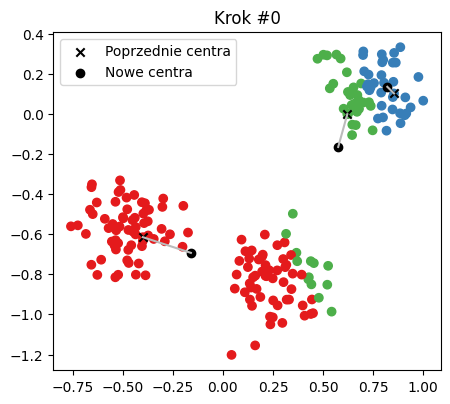

In [32]:
K = 3  # założenie
# wylosujemy K punktów danych jako początkowe centroidy
init_centers = X[np.random.choice(X.shape[0], size=K, replace=False)]
idx, new_centers = kmeans_step(X, init_centers)
show_step(X, idx, init_centers, new_centers, title='Krok #0')

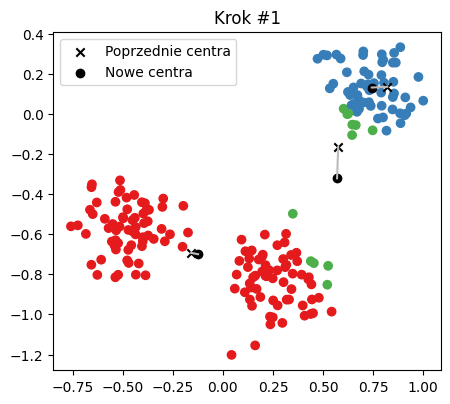

In [33]:
old_centers = new_centers
idx, new_centers = kmeans_step(X, old_centers)
show_step(X, idx, old_centers, new_centers, title='Krok #1')

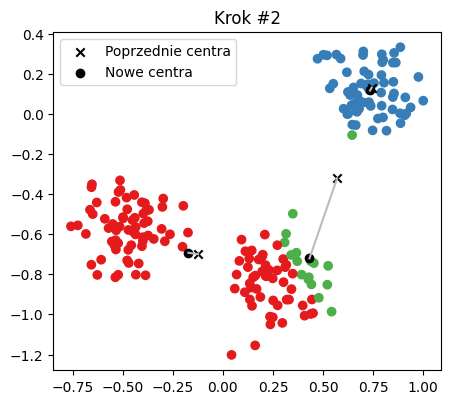

In [34]:
old_centers = new_centers
idx, new_centers = kmeans_step(X, old_centers)
show_step(X, idx, old_centers, new_centers, title='Krok #2')

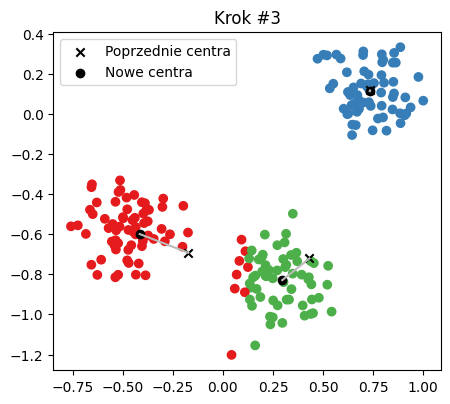

In [35]:
old_centers = new_centers
idx, new_centers = kmeans_step(X, old_centers)
show_step(X, idx, old_centers, new_centers, title='Krok #3')

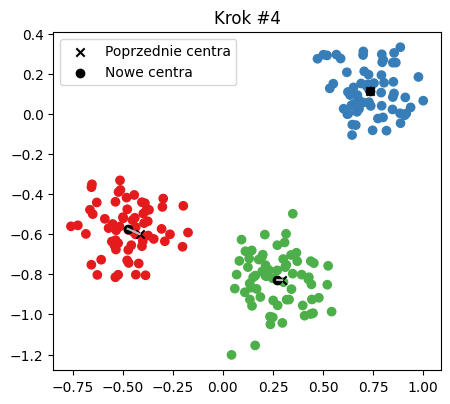

In [36]:
old_centers = new_centers
idx, new_centers = kmeans_step(X, old_centers)
show_step(X, idx, old_centers, new_centers, title='Krok #4')

Jak widać, ten prosty algorytm prowadzi już w kilku krokach do rozwiązania, które bardzo dobrze pokrywa się z ludzką percepcją.
Możesz spróbować powtórzyć powyższe kroki kilkukrotnie, aby zaobserwować różne ścieżki otrzymywania podobnych rozwiązań, może nawet przykłady błędów.

W praktyce musielibyśmy oczywiście powyższą procedurę zaopatrzyć w krok sprawdzenia warunków zakończenia. Twoim zadaniem jest zapoznać się z dokumentacją implementacji `sklearn` algorytmu, [`sklearn.cluster.KMeans`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html). (Tak, to oznacza kliknięcie w link _Read more in the User Guide_ i lekturę zawartości.)

Przykład jego użycia znajduje się poniżej:

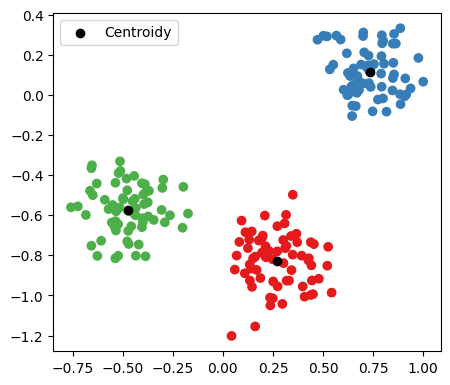

In [16]:
sk_clusters = cluster.KMeans(n_clusters=3).fit(X)
show_simple(X, sk_clusters.labels_, sk_clusters.cluster_centers_)

---

##### Zadanie 1: wpływ parametru $k$ na wynik klasteryzacji

W poprzednim przypadku założyliśmy, że $k$ jest znane, ale w praktyce rzadko kiedy mamy ten komfort. Tymczasem zachowanie algorytmu może znacząco się różnić w zależności od doboru tej wartości. Sprawdź, co się stanie, gdy przyjmiemy zbyt niską bądź zbyt wysoką wartość $k$.

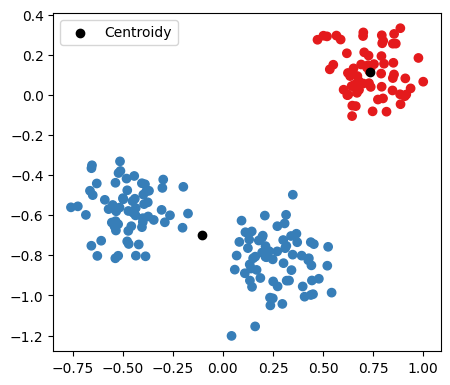

In [37]:
sk_clusters = cluster.KMeans(n_clusters=2).fit(X)
show_simple(X, sk_clusters.labels_, sk_clusters.cluster_centers_)

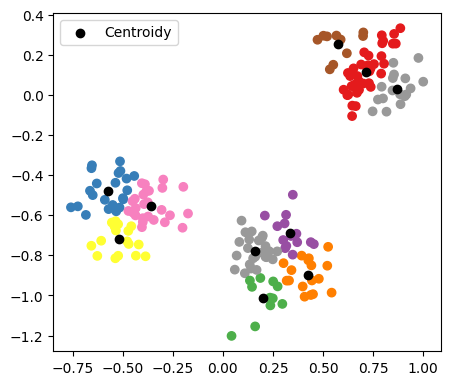

In [27]:
sk_clusters = cluster.KMeans(n_clusters=10).fit(X)
show_simple(X, sk_clusters.labels_, sk_clusters.cluster_centers_)

Zbyt mała wartość $k$ powoduje utratę części informacji (dwie grupy zostały ściśnięte w jeden klaster). Z kolei zbyt duża wartość parametru skutkuje szukaniem podziału i różnic na siłę, tworząc podziały tam gdzie ich nie ma.

##### Zadanie 2: wpływ skali na wynik klasteryzacji

Powyższy przykład zakładał _izotropowość_ zbioru danych; to znaczy, że każdy kierunek (wymiar) jest równorzędny, ponieważ _skala_ była zbliżona w każdym wymiarze. Co stałoby się, gdyby któryś z wymiarów wyraźnie dominował skalą nad innymi?

Wykonaj sztuczne przeskalowanie zbioru danych w taki sposób, że skalowaniu ulegnie jeden z wymiarów zbioru, a drugi pozostanie bez zmian; następnie uruchom algorytm k-średnich na przekształconym zbiorze. Powtórz proces kilka razy, dopóki nie zauważysz problemów.

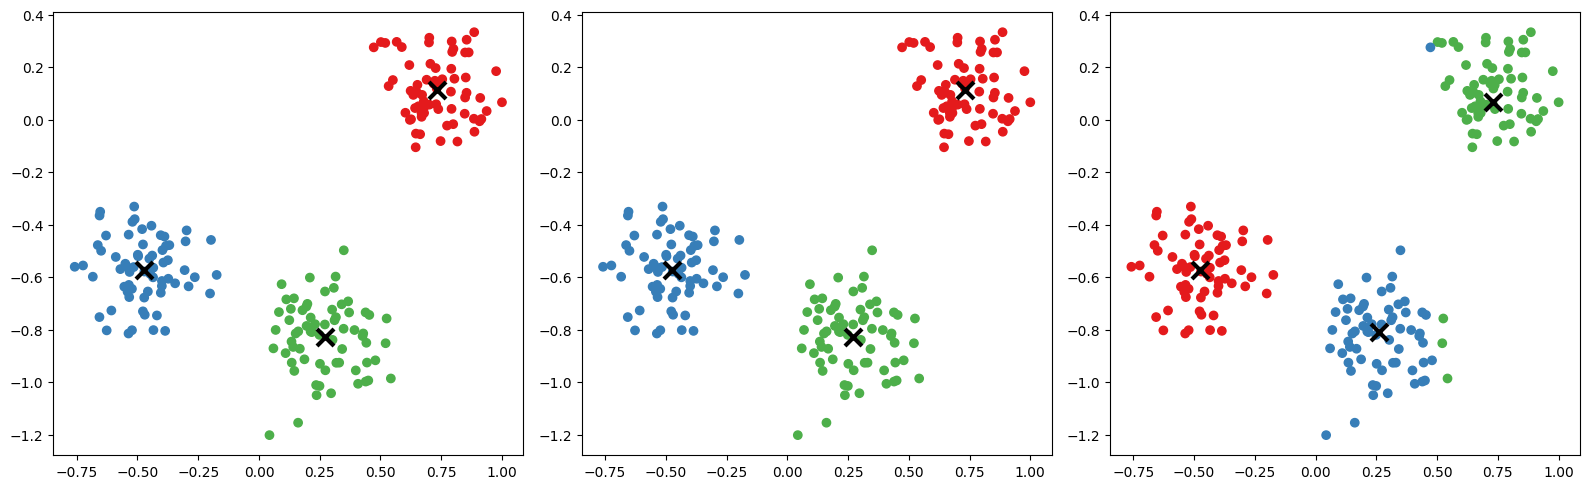

In [56]:
scales = [1, 5, 25]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, scale in enumerate(scales):
    X_scaled = X.copy()
    X_scaled[:, 0] *= scale
    sk_clusters = cluster.KMeans(n_clusters=3).fit(X_scaled)

    axes[i].scatter(X[:, 0], X[:, 1], c=sk_clusters.labels_, cmap='Set1', vmin=0, vmax=8)
    unscaled_centers = sk_clusters.cluster_centers_.copy()
    unscaled_centers[:, 0] = unscaled_centers[:, 0] / scale
    axes[i].scatter(unscaled_centers[:, 0], unscaled_centers[:, 1], marker='x', c='black', s=150, linewidths=3)

plt.tight_layout()
plt.show()

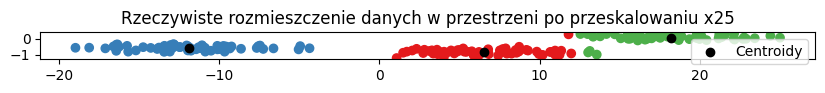

In [58]:
X_scaled_25 = X.copy()
X_scaled_25[:, 0] *= 25

sk_clusters_25 = cluster.KMeans(n_clusters=3, random_state=1009).fit(X_scaled_25)
show_simple(X_scaled_25, sk_clusters_25.labels_, sk_clusters_25.cluster_centers_, figsize=10, aspect='equal')

plt.title("Rzeczywiste rozmieszczenie danych w przestrzeni po przeskalowaniu x25")
plt.show()

Jaki wniosek płynie z powyższego badania?

Kluczowe znaczenie dla algorytmu k-średnich ma odległość na wykresie. Slgorytm jest przez to bardzo wrażliwy na skalowanie, a co za tym idzie na spore różnice w skalach poszczególnych wymiarów. Przed implementacją algorytmu należy uzyć standaryzacji danych.

##### Zadanie 3: wpływ kształtu danych na wynik klasteryzacji

Powyższy przykład zakładał, że dane mają w pewnym sensie "wygodny" kształt, pewnego rodzaju _strukturę_, która umożliwiała efektywne pogrupowanie. W rzeczywistości algorytm k-średnich, jak każdy algorytm, przyjmował różne założenia odnośnie danych, które nie zawsze muszą zachodzić w praktyce.

Poniżej znajdziesz kilka również zabawkowych przykładów, ale o nieco bardziej złożonych kształtach. Przebadaj zachowanie algorytmu k-średnich dla każdego z nich.

Text(0.5, 1.0, 'uniform')

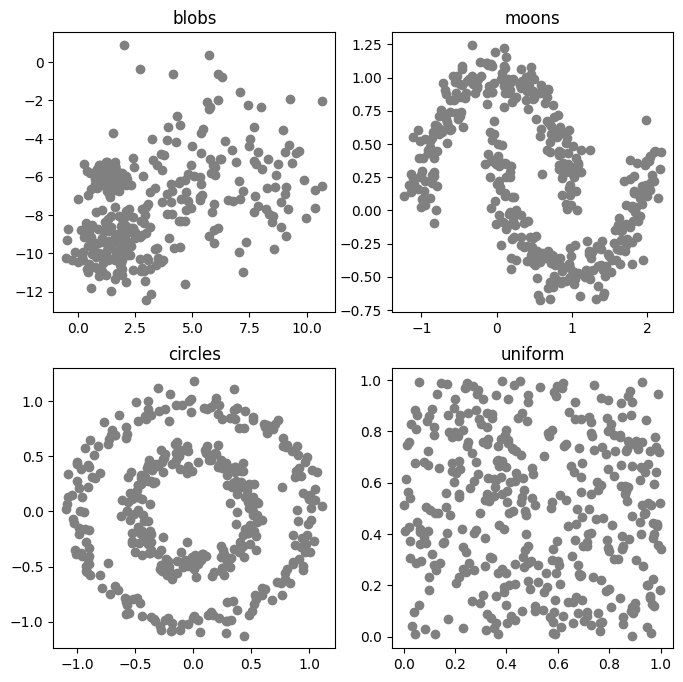

In [59]:
blobs, _ = datasets.make_blobs(n_samples=400, cluster_std=[0.4, 1.0, 2.6], random_state=110001)
moons, _ = datasets.make_moons(n_samples=400, noise=0.1, random_state=2026)
circles, _ = datasets.make_circles(n_samples=400, factor=0.5, noise=0.07, random_state=427)
uniform = np.random.RandomState(0xBEEF).rand(400, 2)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes[0, 0].scatter(blobs[:, 0], blobs[:, 1], c='gray')
axes[0, 0].set_title('blobs')
axes[0, 1].scatter(moons[:, 0], moons[:, 1], c='gray')
axes[0, 1].set_title('moons')
axes[1, 0].scatter(circles[:, 0], circles[:, 1], c='gray')
axes[1, 0].set_title('circles')
axes[1, 1].scatter(uniform[:, 0], uniform[:, 1], c='gray')
axes[1, 1].set_title('uniform')

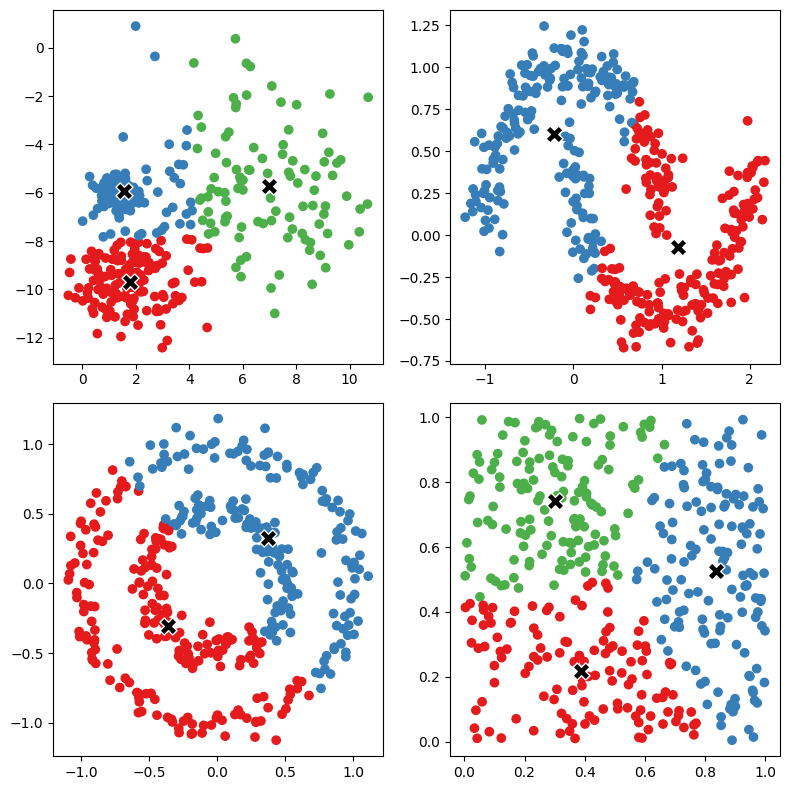

In [64]:
datasets_dict = {
    'blobs': (blobs, 3),
    'moons': (moons, 2),
    'circles': (circles, 2),
    'uniform': (uniform, 3)
}

fig, axes = plt.subplots(2, 2, figsize=(8,8))
axes_flat = axes.flatten()
for i, (dataset_name, (dataset, k)) in enumerate(datasets_dict.items()):
    sk_clusters = cluster.KMeans(n_clusters=k).fit(dataset)
    axes_flat[i].scatter(dataset[:, 0], dataset[:, 1], c=sk_clusters.labels_, cmap='Set1', vmin=0, vmax=8)
    axes_flat[i].scatter(sk_clusters.cluster_centers_[:, 0], sk_clusters.cluster_centers_[:, 1],
                         marker='X', c='black', s=150, edgecolors='white', label='Centroidy')

plt.tight_layout()
plt.show()

Przeanalizuj wyniki eksperymentów w oparciu o wiedzę teoretyczną i dostępne materiały. Dla każdego przypadku problematycznego diagnozuj przyczynę niepowodzenia.

- zbiór `blobs` - założenie, że centroidy mają zbliżony kształt i sztywne granice decyzyjne, algorytm nie bierze pod uwagę lokalnej gęstości

- zbiór `moons` - k-średnich wymaga aby klastry były wypukłe

- zbiór `circles` - aby nastąpił realny podział oba centra musiałyby być w środku okręgów, jednak przez to jeden z nich stałby się bezużyteczny

- zbiór `uniform` - założenie z góry, że istnieje k-klastrów

---

##### Ocena jakości grupowania

Zauważ, że w tak postawionym zadaniu nie musimy, tak jak przy klasyfikacji, szukać (_indukować_) żadnej funkcji czy reguły decyzyjnej. W ogólnym sformułowaniu\* zależy nam jedynie na jednorazowym znalezieniu zbioru identyfikatorów $\hat{Y}$, a więc mówimy o tzw. _transdukcji_. W związku z tym traci sens koncepcja _uogólniania_, a w konsekwencji również pojęcia "zbioru uczącego" i "zbioru testowego". Ocenić możemy jedynie _ten konkretny_ wynik grupowania.

Pytanie jednak _jak to zrobić_, skoro, zgodnie z fundamentalnym założeniem, nie mamy dostępu do prawdziwych etykiet $Y$?

Wyróżnia się cztery grupy podejść do oceny jakości klasteryzacji, każda ze swoimi wadami i zaletami:
* ocena manualna - człowiek-ekspert w sobie znany (i subiektywny) sposób ocenia jakość wyniku (dotąd tutorial oparty był o tę metodę),
* metody oceny _wewnętrznej_ - pomiar jakiejś wielkości matematycznej dla znalezionych przez algorytm klastrów,
* metody oceny _zewnętrznej_ - zakłada, że jednak mamy dostęp do zbioru $Y$ i możemy porównać uzyskane klastry z anotacjami,
* ocena pośrednia - kiedy klasteryzacja jest tylko etapem w większym potoku przetwarzania, kończącym się zwróceniem jakiegoś wyniku, który to możemy w ilościowy sposób ocenić (tj. oceniamy wpływ klasteryzacji na finalny wynik, a nie wynik klasteryzacji sam w sobie).

Wśród metryk wewnętrznych, jedną z prostszych do zrozumienia jest tzw. [współczynnik _silhouette_](https://scikit-learn.org/stable/modules/clustering.html#silhouette-coefficient) (wymowa: _syluet_). Klastry "lepsze" w sensie silhouette cechują się tym, że (1) średnie odległości pomiędzy punktami wewnątrz klastra są niskie, oraz (2) średnie odległości pomiędzy punktami wewnątrz klastra a punktami należącymi do najbliższego innego klastra są wysokie. Zaletą tej metryki jest, że można wyznaczyć jej wartości nie tylko dla całego zbioru $X$, ale dla każdego punktu $x \in X$, oceniając tym samym jakość dopasowania na poziomie poszczególnych punktów. Wady obejmują złożoność obliczeniową oraz zależność od kształtu zbioru danych samego w sobie. Doczytaj o szczegółach tej metryki pod linkiem powyżej.

W przypadku metryk zewnętrznych, działają one nieco podobnie jak w przypadku klasyfikacji, z istotną różnicą niezmienniczości na permutacje. To znaczy, "jakość" nie zależy od tego jakie _konkretnie_ wartości indeksu klastra $\hat{y}$ zostaną przypisane danej próbce, liczy się jedynie przypisanie do odpowiednich grup. Łatwo to zobaczyć na przykładzie. Rozważmy dwa możliwe wyniki grupowania, $\hat{Y_1}$ i $\hat{Y_2}$:
$$\hat{Y_1} = {1, 0, 1, 1, 2, 2, 0, 0, 2, 1, 1, 0}$$
$$\hat{Y_2} = {1, 2, 1, 1, 0, 0, 2, 2, 0, 1, 1, 2}$$
Część próbek w $\hat{Y_1}$ została oznaczona jako klaster o indeksie 0 a część jako 2; $\hat{Y_2}$ różni się jedynie permutacją indeksów 0 i 2, ale funkcjonalnie stanowi identyczne grupowanie.

Prostym przykładem metryki oceny jakości zewnętrznej jest miara [_purity_](https://en.wikipedia.org/wiki/Cluster_analysis#Purity) ("czystość"). Mierzy ona stopień, w jakim klastry wynikowe zawierają przykłady z tylko jednej klasy. Maksymalną wartością jest $1.0$ osiągane wtedy i tylko wtedy, gdy każdy klaster idealnie odpowiada którejś klasie. Im więcej wtrąceń z pozostałych klas, tym niższa wartość purity. Miara ta ma więc bardzo prostą, intuicyjną interpretację, jednak łatwo ją "oszukać" ustawiając bardzo wysoką liczbę klastrów (w szczególności, dla $K=N$ zawsze otrzymamy $\text{purity} = 1.0$), oraz jest podatna na przekłamania wynikające z imbalansu klas.

Ponieważ pakiet `sklearn` nie zawiera implementacji miary purity (zamiast tego oferuje wskaźnik [`homogeneity_score`](https://scikit-learn.org/stable/modules/clustering.html#homogeneity-completeness-and-v-measure), który jednak jest nieco zbyt złożony, by go dokładnie w tym momencie omówić), w następnej komórce znajdziesz gotową implementację. Zapoznaj się z nią przed użyciem, w szczególności z funkcją [`contingency_matrix`](https://scikit-learn.org/stable/modules/clustering.html#contingency-matrix).

\* - Niektóre algorytmy klasteryzacji, wśród nich k-średnich, pozwalają na automatyczne wyznaczenie reguły decyzyjnej. Nie jest to jednak własność uniwersalna.

In [30]:
def purity_score(labels_true: np.ndarray, labels_pred: np.ndarray) -> float:
    # 1. Oblicz macierz contingency (podobna do macierzy pomyłek - doczytaj)
    # Jej wiersze odpowiadają klasom (Y), a kolumny klastrom (przewidzianym)
    cont_matrix = metrics.cluster.contingency_matrix(labels_true, labels_pred)

    # 2. Dla każdego klastra oblicz maksymalną liczbę należących do niego przykładów z jednej klasy
    max_per_cluster = np.max(cont_matrix, axis=0)

    # 3. Zsumuj te maksymalne wartości i podziel przez całkowitą liczbę przykładów
    return np.sum(max_per_cluster) / np.sum(cont_matrix)